In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from sklearn.datasets import load_wine

wine = load_wine()
X = wine.data
y = wine.target
print(y)
print(X.shape, y.shape)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
(178, 13) (178,)


In [3]:
import sklearn.linear_model as lm 

logr = lm.LogisticRegression()
logr.fit(X,y)
logr.score(X,y)

c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9662921348314607

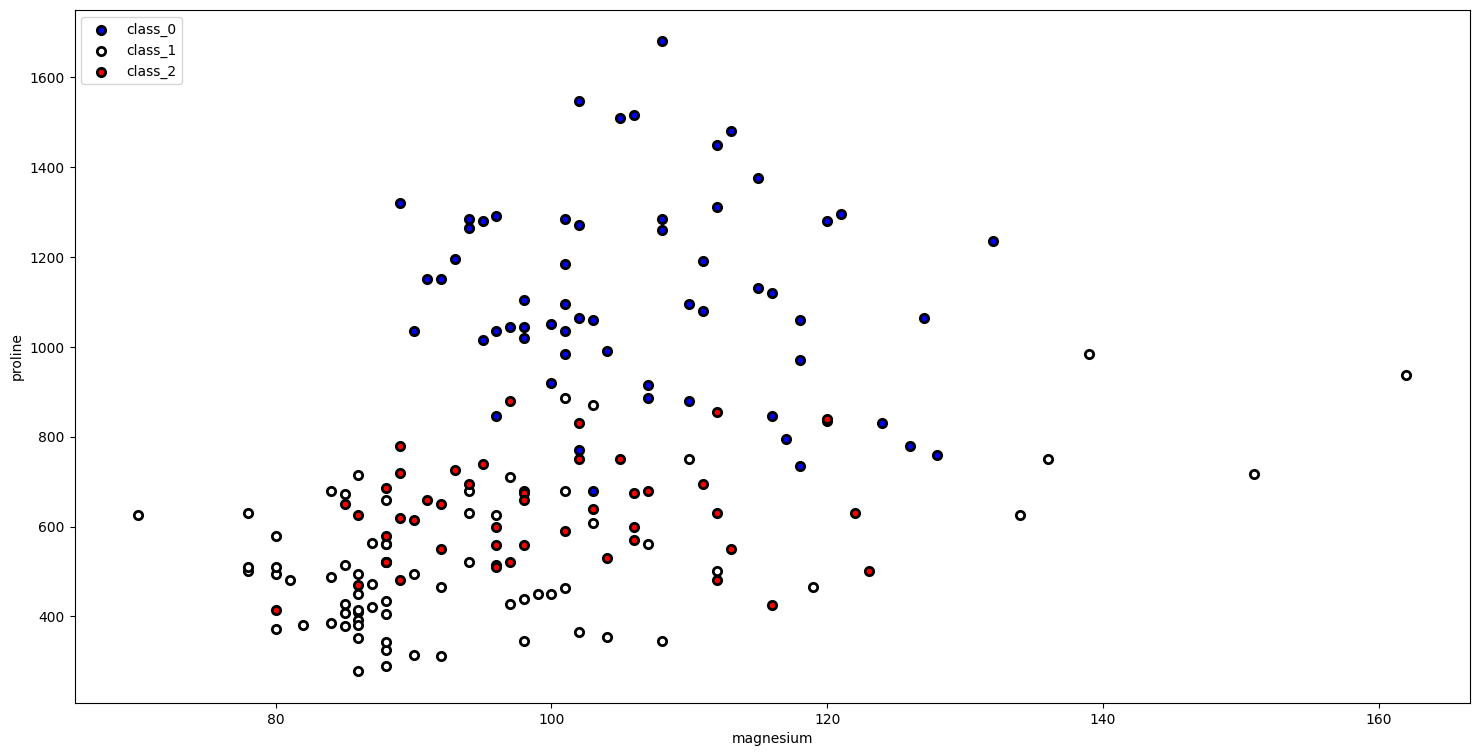

In [4]:
n_classes = 3
colors = 'bwr'
CMAP = colors # Farbpalette
plot_step = 0.01

fig = plt.figure(1, figsize=(18, 9))

# Berücksichtigung von paarweisen Korrelationen 
pair = [4,12]
X = wine.data[:, pair]
y = wine.target

clf = logr.fit(X, y)

# Achsen und Größe des Subplots
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                        np.arange(y_min, y_max, plot_step))

# Labeln des Subplots
plt.xlabel(wine.feature_names[pair[0]])
plt.ylabel(wine.feature_names[pair[1]]) 
plt.axis("tight")

# Pltten der ausgewerteten Datenpunkte
for i, color in zip(range(n_classes), colors):
    idx = np.where(y == i)
    plt.scatter(X[idx, 0], X[idx, 1], c=color, edgecolor="black", lw=2, label= wine.target_names[i])
        

    plt.axis("tight")
    plt.legend(loc="upper left")

In [5]:

for i in range(wine.data.shape[1]):
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12


In [6]:
list_of_pairs = []
for first_coordinate in range(wine.data.shape[1]):
    for second_coordinate in range(first_coordinate+1, wine.data.shape[1]):
        pair = [first_coordinate, second_coordinate]
        list_of_pairs.append(pair)

list_of_pairs[2:8]

[[0, 3], [0, 4], [0, 5], [0, 6], [0, 7], [0, 8]]

c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


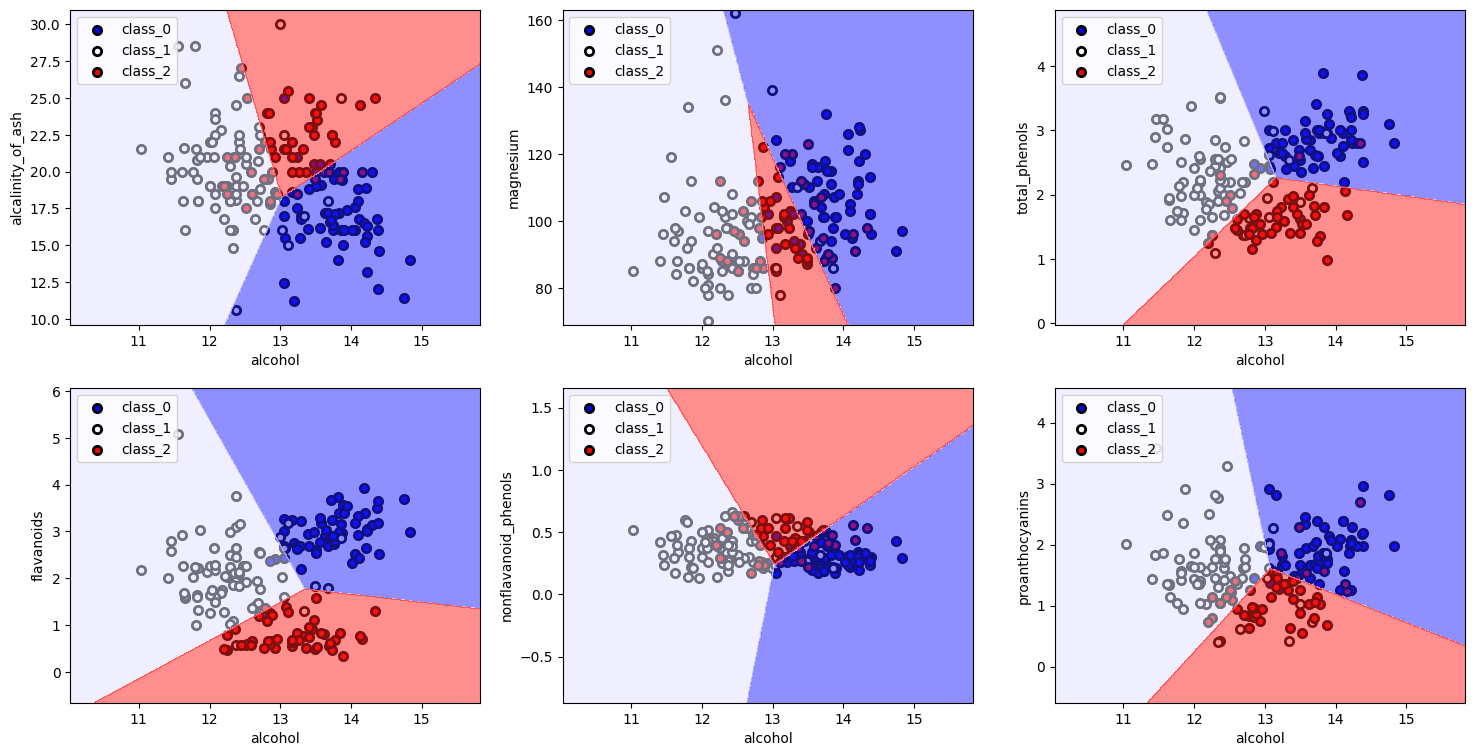

In [7]:
n_classes = 3
colors = 'bwr'
CMAP = colors # Farbpalette
plot_step = 0.01

fig = plt.figure(1, figsize=(18, 9))

# Berücksichtigung von paarweisen Korrelationen 
for pairidx, pair in enumerate(list_of_pairs[2:8]):
    X = wine.data[:, pair]
    y = wine.target

    clf = logr.fit(X, y)

    # Plotten jedes einzelnen Subplots
    plt.subplot(2, 3, pairidx + 1)

    # Achsen und Größe des Subplots
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    # Labeln des Subplots
    plt.xlabel(wine.feature_names[pair[0]])
    plt.ylabel(wine.feature_names[pair[1]]) 
    plt.axis("tight")

    # Pltten der ausgewerteten Datenpunkte
    for i, color in zip(range(n_classes), colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, edgecolor="black", lw=2, label=wine.target_names[i])
        
    # Plotten und einfärben der getrennten Klassen
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, alpha=0.5, cmap = CMAP)

    plt.axis("tight")
    plt.legend(loc="upper left")